In [5]:
import os, sys, json
import numpy as np
import pandas as pd
from astropy.table import Table
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [7]:
path_data = "../data/Synphot/New_Photometry/final_synphot_normal_class.csv"

In [8]:
intbl = Table.read(path_data)

In [9]:
subtbl = intbl[intbl['type'] == 'Asteroid']

In [29]:
keys = subtbl.keys()
keys_magobs = []
keys_magobserr = []
wavelengths = []
bandwidth = 25./2.
ii = 0

prefix = "magobs_m"

for key in keys:
    if prefix in key:
        keys_magobs.append(key)
        
        wavelengths.append(float(key.split("_")[-1][1:]))
    if 'magerr_m' in key:
        keys_magobserr.append(key)

# keys_magobs
# wavelengths
# keys_magobserr

In [56]:
types = [os.path.basename(spec).split("_")[1] for spec in subtbl['spec']]
len(types)

9582

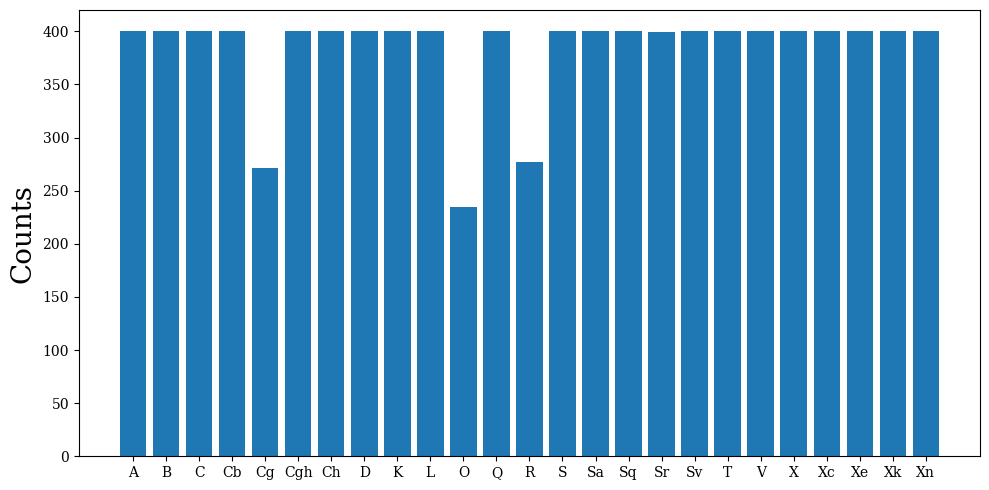

In [64]:
unique_types, types_counts = np.unique(types, return_counts=True)

fig = plt.figure(figsize=(10, 5))
plt.bar(unique_types, types_counts)

plt.ylabel("Counts")
plt.tight_layout()

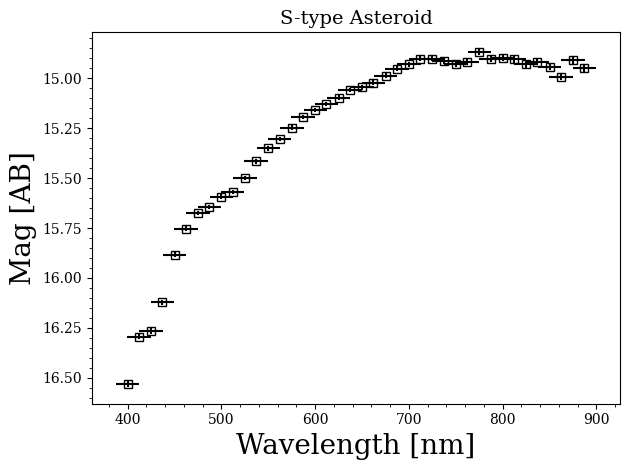

In [65]:
# for ii in [1000, 2000, 3000, 4000, 5000]:
for ii in np.arange(len(subtbl)):
    typ = types[ii]
    if typ == "S":
        magobs_arr = np.array([subtbl[key][ii] for key in keys_magobs])
        magerr_arr = np.array([subtbl[key][ii] for key in keys_magobserr])

        if np.min(magobs_arr) < 15:
            
            plt.plot(wavelengths, magobs_arr, marker='s', ls='', mfc='none', mec='k')
            plt.errorbar(wavelengths, magobs_arr, xerr=bandwidth, yerr=magerr_arr, ls='none', c='k')
            yl, yu = plt.ylim()
            plt.ylim(yu, yl)
            plt.ylabel("Mag [AB]")
            plt.xlabel("Wavelength [nm]")
            plt.title(f"{typ}-type Asteroid")
            plt.minorticks_on()
            plt.tight_layout()
            plt.show()
            break 